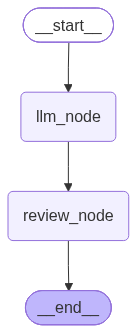

============================== -> interrupt_res <- ==============================
{'topic': '布偶猫', 'poem': '布偶仙姿入画来，\n碧蓝眼眸似海洋。\n温顺依人常伴膝，\n慵懒娇憨惹人赏。', '__interrupt__': [Interrupt(value={'instruction': '请审核并修改大模型生成的七言绝句', 'poem': '布偶仙姿入画来，\n碧蓝眼眸似海洋。\n温顺依人常伴膝，\n慵懒娇憨惹人赏。'}, id='45affd79902273eac173da3348e8eb85')]}
原始诗句：
布偶仙姿入画来，
碧蓝眼眸似海洋。
温顺依人常伴膝，
慵懒娇憨惹人赏。
============================== -> reviewed_res <- ==============================
{'topic': '布偶猫', 'poem': '布偶仙姿入画来，\n碧蓝眼眸似海洋。\n温顺依人常伴膝，\n慵懒娇憨惹人赏。', 'reviewed_poem': 'ok'}
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm_node(llm_node)
	review_node(review_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm_node;
	llm_node --> review_node;
	review_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from rich import print as rprint

load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    reviewed_poem: str

def llm_node(state: OverAllState) -> OverAllState:
    topic = state['topic']

    res = model.invoke([HumanMessage(content=f"帮我写一首关于 {topic} 的七言绝句，只给出诗句，不要赏析")]).content
    return {
        "poem": res
    }

def review_node(state: OverAllState) -> OverAllState:
    reviewed_poem = interrupt({
        "instruction": "请审核并修改大模型生成的七言绝句",
        "poem": state['poem']
    })
    return {
        "reviewed_poem": reviewed_poem
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("llm_node", llm_node)
builder.add_node("review_node", review_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "review_node")
builder.add_edge("review_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "review_test"}}
interrupted_res = graph.invoke({"topic": "布偶猫"}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

print("原始诗句：")
print(interrupted_res['__interrupt__'][0].value['poem'])
user_review = input("请审核并修改诗句（直接回车保留原诗）: ")
if not user_review.strip():
    user_review = interrupted_res['__interrupt__'][0].value['poem']
reviewed_res = graph.invoke(Command(resume=user_review), config=config)
print('=' * 30, '-> reviewed_res <-', '=' * 30)
print(reviewed_res)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)